# Núcleo 2 — Aporte vs. recibo por provincia

Compara, para cada una de las 24 jurisdicciones, cuánto **aporta** a la economía
nacional (usando el Producto Bruto Geográfico, PBG, como proxy) contra cuánto
**recibe** de la coparticipación federal (según el coeficiente fijo de la Ley 23.548).
El objetivo es identificar provincias "ganadoras" y "perdedoras" relativas al esquema
de reparto vigente, que no se actualizó desde 1988 pese a los cambios en el peso
económico relativo de cada provincia.

**Fuentes**:
- PBG: CEPAL, año 2024 (el más reciente disponible; dato preliminar en la fuente
  original). `data/raw/pbg/Jurisdiccion_52sectores.xlsx`.
- Coeficientes de coparticipación: Ley 23.548, con el valor de CABA actualizado
  manualmente a 1,4% (el original de la fuente, de 2018, tenía 3,75%).
  `data/raw/coeficientes/indices_copa_2018.pdf`.

Ver `docs/methodology.md` para el detalle completo de cómo se construyó cada columna y
por qué **no se comparan como partes de un mismo 100%** (son fracciones de dos
"totales nacionales" distintos: el PBG país y la masa coparticipable total).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

COLOR_POSITIVO = "#2a78d6"   # recibe más de lo que aporta (proxy PBG)
COLOR_NEGATIVO = "#e34948"   # recibe menos de lo que aporta
COLOR_CORDOBA_BORDE = "#0b0b0b"

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

BASE_DIR = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
FIGURES_DIR = BASE_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE_DIR / "data" / "processed" / "aporte_vs_recibo.csv")
df

,provincia,pct_pbg_aporte,pct_coparticipacion_recibe,diferencia_pp
0,Formosa,0.005217,0.020661,1.544441
1,Chaco,0.015124,0.028314,1.319022
2,Catamarca,0.006526,0.015633,0.910655
3,Corrientes,0.012667,0.021099,0.843204
4,Tucumán,0.018964,0.027002,0.803769
5,Santiago del Estero,0.015860,0.023449,0.758954
6,La Rioja,0.005481,0.011752,0.627121
7,San Juan,0.013126,0.019186,0.605983
8,Misiones,0.012791,0.018748,0.595744
9,Jujuy,0.010343,0.016125,0.578178


## 1. Columnas

- `pct_pbg_aporte`: % del PBG de esa provincia sobre el PBG total del país (2024).
- `pct_coparticipacion_recibe`: % de la masa coparticipable total que recibe esa
  provincia, según su coeficiente de Ley 23.548.
- `diferencia_pp`: `pct_coparticipacion_recibe - pct_pbg_aporte`, en puntos
  porcentuales. Positivo = recibe proporcionalmente más de lo que "aporta" según este
  proxy; negativo = lo contrario.

In [2]:
assert len(df) == 24, "Se esperaban 24 jurisdicciones"
df[["pct_pbg_aporte", "pct_coparticipacion_recibe"]].describe()

,pct_pbg_aporte,pct_coparticipacion_recibe
count,24.000000,24.000000
mean,0.041642,0.024483
std,0.072267,0.024108
min,0.005217,0.007000
25%,0.010439,0.012654
50%,0.014766,0.018967
75%,0.029038,0.024501
max,0.318482,0.124638


## 2. Ranking de las 24 jurisdicciones por diferencia

Ordenadas de mayor "ganadora" (recibe mucho más de lo que aporta) a mayor "perdedora".

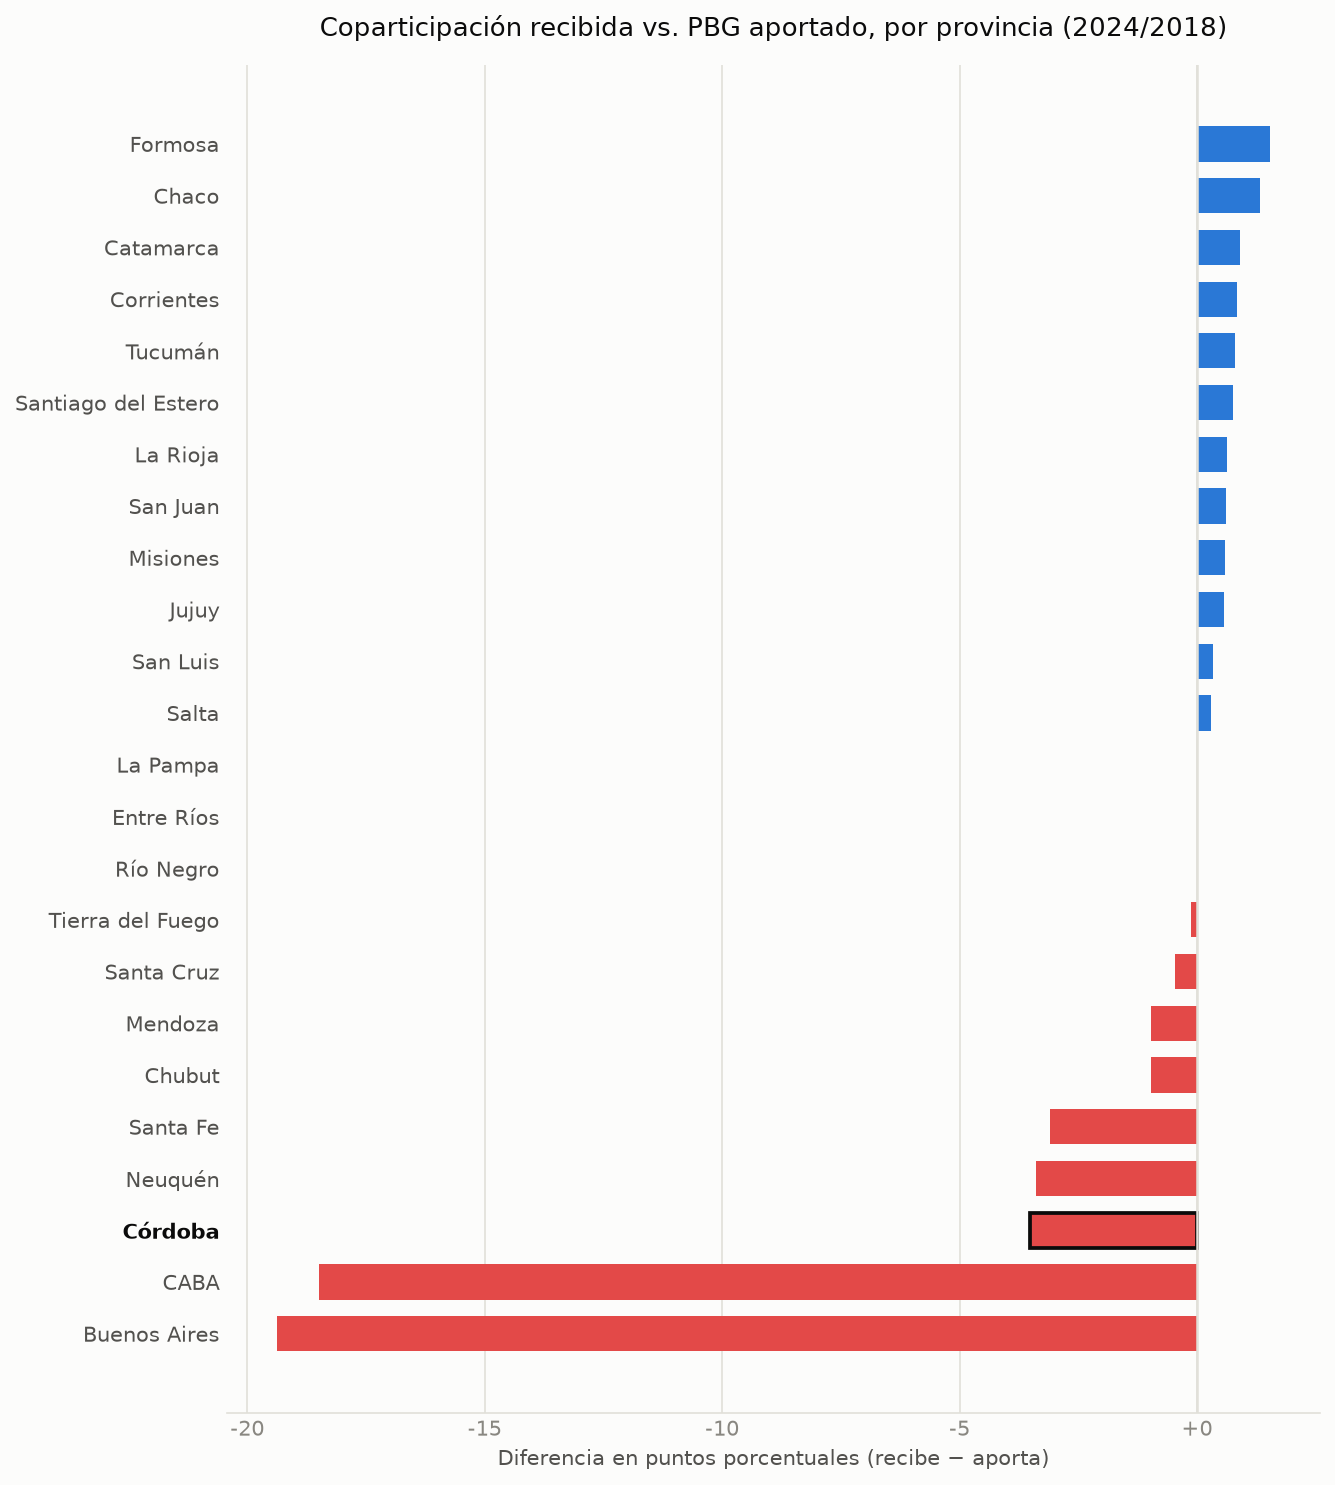

In [3]:
orden = df.sort_values("diferencia_pp", ascending=True).reset_index(drop=True)
colores = [COLOR_POSITIVO if v >= 0 else COLOR_NEGATIVO for v in orden["diferencia_pp"]]
bordes = [COLOR_CORDOBA_BORDE if p == "Córdoba" else "none" for p in orden["provincia"]]
grosor_borde = [1.8 if p == "Córdoba" else 0 for p in orden["provincia"]]

fig, ax = plt.subplots(figsize=(9, 10), dpi=150)
bars = ax.barh(
    orden["provincia"], orden["diferencia_pp"],
    color=colores, edgecolor=bordes, linewidth=grosor_borde, height=0.68,
)

ax.axvline(0, color=GRID_COLOR, linewidth=1.2)
ax.set_title(
    "Coparticipación recibida vs. PBG aportado, por provincia (2024/2018)",
    fontsize=12.5, color=INK_PRIMARY, pad=14,
)
ax.set_xlabel("Diferencia en puntos porcentuales (recibe − aporta)", fontsize=10)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}"))

# Resaltar la etiqueta de Córdoba en el eje y
for label in ax.get_yticklabels():
    if label.get_text() == "Córdoba":
        label.set_fontweight("bold")
        label.set_color(INK_PRIMARY)
    else:
        label.set_color(INK_SECONDARY)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "aporte_vs_recibo_ranking.png", dpi=300, facecolor=SURFACE)
plt.show()

**Dónde queda Córdoba**: recibe 5,04% de la coparticipación pero representa 8,56% del
PBG nacional -- una diferencia de **-3,52 puntos porcentuales**, la tercera peor brecha
del país después de Buenos Aires (-19,4 pp) y CABA (-18,5 pp). Córdoba está en el grupo
de provincias "aportantes netas" según este proxy: economías grandes y desarrolladas
(Buenos Aires, CABA, Córdoba, Santa Fe, Neuquén) reciben proporcionalmente menos de lo
que su peso económico sugeriría, mientras que las provincias del NEA y NOA (Formosa,
Chaco, Catamarca) reciben bastante más. Esto es consistente con el objetivo original
del régimen de 1988: redistribuir hacia las provincias de menor desarrollo relativo.

## 3. Limitaciones de este análisis

**Esto no es una medición directa de cuánto aporta cada provincia a la recaudación
tributaria nacional coparticipable.** El PBG es un proxy, y tiene un problema de
atribución geográfica conocido y significativo:

- **Las grandes empresas suelen tributar donde tienen su sede fiscal, no donde generan
  la actividad económica.** Muchas empresas con operaciones en todo el país tienen su
  domicilio fiscal en CABA, así que buena parte de la recaudación de Ganancias, IVA y
  otros impuestos nacionales que en la práctica se genera en otras provincias (incluida
  Córdoba) queda contabilizada como aporte tributario "de CABA" en las estadísticas
  oficiales de recaudación -- pero el **PBG sí mide dónde se genera la actividad
  económica real**, no dónde se paga el impuesto. Esto probablemente **subestima el
  aporte tributario real de CABA en términos de PBG** (su PBG ya es alto por
  concentrar sedes corporativas, servicios financieros y profesionales) y por lo tanto
  el análisis puede estar **sobreestimando qué tan "perdedora" es CABA** en términos de
  aporte tributario real vs. recibo -- o, mirado al revés, el aporte tributario
  efectivo de provincias productivas como Córdoba podría estar mejor reflejado en la
  recaudación nacional de lo que este análisis (basado solo en PBG) sugiere.
- **El PBG (2024) y el coeficiente de coparticipación (fijado en 1988, con ajustes
  puntuales) no son directamente comparables como partes de un mismo 100%.** El PBG
  suma 100% entre las 24 jurisdicciones (más una porción "no distribuida"); el
  coeficiente de coparticipación de las 24 jurisdicciones suma solo ~61% de la masa
  coparticipable total (el resto queda en la Nación y el Fondo de Aportes del Tesoro).
  La comparación es de orden de magnitud entre dos fracciones de "totales nacionales"
  distintos, no una relación exacta.
- **El PBG usado es de un solo año (2024, preliminar)** mientras que el coeficiente de
  coparticipación es esencialmente fijo desde 1988 (con la excepción de ajustes como el
  de CABA). Comparar un dato de estructura económica de un año puntual contra un
  coeficiente que no se mueve en el tiempo no captura cómo cambió el peso relativo de
  cada provincia a lo largo de casi 40 años -- que es, de hecho, el punto central del
  argumento de que el esquema de 1988 está desactualizado.
- Un análisis más riguroso del "aporte" tributario real requeriría datos de recaudación
  por jurisdicción de origen económico (no de domicilio fiscal), que no están
  fácilmente disponibles de forma pública y desagregada por provincia.